# Imports

In [31]:
import os
import cv2
import random
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from google.colab import drive
import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras import mixed_precision
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.applications import EfficientNetB0
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, ModelCheckpoint

In [32]:
# Load and unzip the dataset

In [33]:
drive.mount('/content/drive')

with zipfile.ZipFile('/content/drive/MyDrive/Colab Notebooks/Stanford_Balanced.zip', 'r') as z:
    z.extractall('/content/data/')

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Split the data by patient (Train 80%, Test 10%, Validation 10%)

In [34]:
train_dir = "/content/data/Stanford_Balanced/"
labels = ["Benign", "Malignant"]
image_size = 256

file_paths = []
patient_ids = []
image_labels = []

print("Scanning folders to map Patient IDs to files")
for label in labels:
    folderPath = os.path.join(train_dir, label)
    if not os.path.exists(folderPath):
        continue

    for image_name in os.listdir(folderPath):
        p_id = image_name.split('_')[0]

        file_paths.append(os.path.join(folderPath, image_name))
        patient_ids.append(p_id)
        image_labels.append(labels.index(label))

df = pd.DataFrame({
    'path': file_paths,
    'patient_id': patient_ids,
    'label': image_labels
})

print(f"\n--- Before Balancing ---")
print(f"Total frames found: {len(df)}")
print(f"Unique patients found: {df['patient_id'].nunique()}")


TARGET_IMAGES = 50

patient_counts = df['patient_id'].value_counts()

valid_patients = patient_counts[patient_counts >= TARGET_IMAGES].index

filtered_df = df[df['patient_id'].isin(valid_patients)]

balanced_df = filtered_df.groupby('patient_id').sample(n=TARGET_IMAGES, random_state=42)

balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

df = balanced_df

print(f"\n--- After Balancing (Evrey patient has {TARGET_IMAGES} images) ---")
print(f"New Image total: {len(df)}")
print(f"Patients: {df['patient_id'].nunique()}")

Scanning folders to map Patient IDs to files

--- Before Balancing ---
Total frames found: 11154
Unique patients found: 124

--- After Balancing (Evrey patient has 50 images) ---
New Image total: 4750
Patients: 95


In [35]:
patient_df = df.drop_duplicates(subset='patient_id')

train_pts, temp_pts = train_test_split(
    patient_df['patient_id'],
    test_size=0.20,
    stratify=patient_df['label'],
    random_state=23
)

val_pts, test_pts = train_test_split(
    temp_pts,
    test_size=0.50,
    stratify=patient_df[patient_df['patient_id'].isin(temp_pts)]['label'],
    random_state=23
)

train_df = df[df['patient_id'].isin(train_pts)]
val_df = df[df['patient_id'].isin(val_pts)]
test_df = df[df['patient_id'].isin(test_pts)]


# Image Preprocessing

In [36]:
def auto_crop_ultrasound(image):

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)

        x, y, w, h = cv2.boundingRect(largest_contour)


        margin = 5
        x_new = max(0, x + margin)
        y_new = max(0, y + margin)
        w_new = max(10, w - 2*margin)
        h_new = max(10, h - 2*margin)

        cropped_image = image[y_new:y_new+h_new, x_new:x_new+w_new]
        return cropped_image

    return image

def load_images_from_df(target_df, desc):
    images = []
    lbls = []
    for _, row in tqdm(target_df.iterrows(), total=len(target_df), desc=desc):
        img = cv2.imread(row['path'])
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = auto_crop_ultrasound(img)

            img = cv2.resize(img, (image_size, image_size))

            img = preprocess_input(img)

            images.append(img)
            lbls.append(row['label'])

    return np.array(images), np.array(lbls)
print("Loading image data into memory arrays")
X_train, y_train_integers = load_images_from_df(train_df, "Training Set")
X_val, y_val_integers = load_images_from_df(val_df, "Validation Set")
X_test, y_test_integers = load_images_from_df(test_df, "Test Set")

Loading image data into memory arrays


Test Set: 100%|██████████| 500/500 [00:05<00:00, 93.31it/s]


# Data Augmantation

In [37]:
class_weights = compute_class_weight(
    'balanced', classes=np.unique(y_train_integers), y=y_train_integers
)
class_weights_dict = dict(enumerate(class_weights))
print("Calculated Class Weights:", class_weights_dict)

y_train = y_train_integers
y_val = y_val_integers
y_test = y_test_integers

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

train_generator = train_datagen.flow(X_train, y_train, batch_size=32, seed=42)

Calculated Class Weights: {0: np.float64(0.95), 1: np.float64(1.0555555555555556)}


# Model Training

In [38]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(image_size, image_size, 3))

for layer in base_model.layers[-20:]:
    layer.trainable = False
for layer in base_model.layers[-70:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.7)(x)
output = Dense(1, activation='sigmoid', kernel_regularizer=l2(0.01), dtype='float32')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.AUC(name='pr_auc', curve='PR'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks = [
    ModelCheckpoint("Thyroid_PatientSplit_Best.keras", monitor="val_loss", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

print("\n--- Starting Training (Base Model Frozen) ---")
history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // 32,
    validation_data=(X_val, y_val),
    epochs=40,
    class_weight=class_weights_dict,
    callbacks=callbacks
)


--- Starting Training (Base Model Frozen) ---
Epoch 1/40
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6057 - auc: 0.6380 - loss: 1.0771 - pr_auc: 0.6269 - precision: 0.6009 - recall: 0.5783
Epoch 1: val_loss improved from None to 0.95371, saving model to Thyroid_PatientSplit_Best.keras

Epoch 1: finished saving model to Thyroid_PatientSplit_Best.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.6940 - auc: 0.7516 - loss: 0.8057 - pr_auc: 0.7297 - precision: 0.6834 - recall: 0.6609 - val_accuracy: 0.4511 - val_auc: 0.4005 - val_loss: 0.9537 - val_pr_auc: 0.4868 - val_precision: 0.5055 - val_recall: 0.5520 - learning_rate: 0.0010
Epoch 2/40
  1/118 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - accuracy: 0.7812 - auc: 0.8421 - loss: 0.5642 - pr_auc: 0.8017 - precision: 0.7143 - recall: 0.7692

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss did not improve from 0.95371
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7812 - auc: 0.8421 - loss: 0.5642 - pr_auc: 0.8017 - precision: 0.7143 - recall: 0.7692 - val_accuracy: 0.4311 - val_auc: 0.4003 - val_loss: 0.9662 - val_pr_auc: 0.4861 - val_precision: 0.4885 - val_recall: 0.5080 - learning_rate: 0.0010
Epoch 3/40
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.8537 - auc: 0.9311 - loss: 0.3634 - pr_auc: 0.9293 - precision: 0.8413 - recall: 0.8512
Epoch 3: val_loss did not improve from 0.95371
118/118 ━━━━━━━━━━━━━━━━━━━━ 53s 452ms/step - accuracy: 0.8649 - auc: 0.9408 - loss: 0.3386 - pr_auc: 0.9368 - precision: 0.8502 - recall: 0.8669 - val_accuracy: 0.4222 - val_auc: 0.3946 - val_loss: 2.5596 - val_pr_auc: 0.4748 - val_precision: 0.4621 - val_recall: 0.2440 - learning_rate: 0.0010
Epoch 4/40
  1/118 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - accuracy: 0.9688 - auc: 1.0000 - loss: 0.1095 - pr_auc: 1.0000 - precision: 1.0000 - recall: 0.9474
Epoch

# Model Evaluation


Final Evaluation on Test Set (Binary Classification):
16/16 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step
--- Classification Report (Threshold: 0.6) ---
               precision    recall  f1-score   support

   Benign (0)       0.85      0.71      0.77       300
Malignant (1)       0.65      0.81      0.72       200

     accuracy                           0.75       500
    macro avg       0.75      0.76      0.75       500
 weighted avg       0.77      0.75      0.75       500


--- Confusion Matrix ---
[[213  87]
 [ 39 161]]


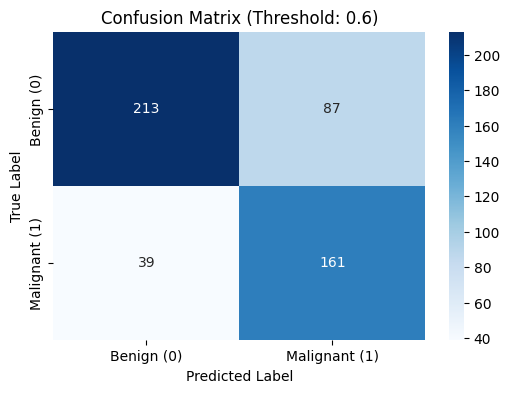

In [39]:
print("\nFinal Evaluation on Test Set (Binary Classification):")
best_model = tf.keras.models.load_model("Thyroid_PatientSplit_Best.keras")

pred_probs = best_model.predict(X_test)

threshold = 0.60
pred_classes = np.where(pred_probs > threshold, 1, 0)

target_names = ["Benign (0)", "Malignant (1)"]

print(f"--- Classification Report (Threshold: {threshold}) ---")
print(classification_report(y_test_integers, pred_classes, target_names=target_names))

cm = confusion_matrix(y_test_integers, pred_classes)
print("\n--- Confusion Matrix ---")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Threshold: {threshold})')
plt.show()

# GradCam Visualization

Image Loading: /content/data/Stanford_Balanced/Benign/145__5.png


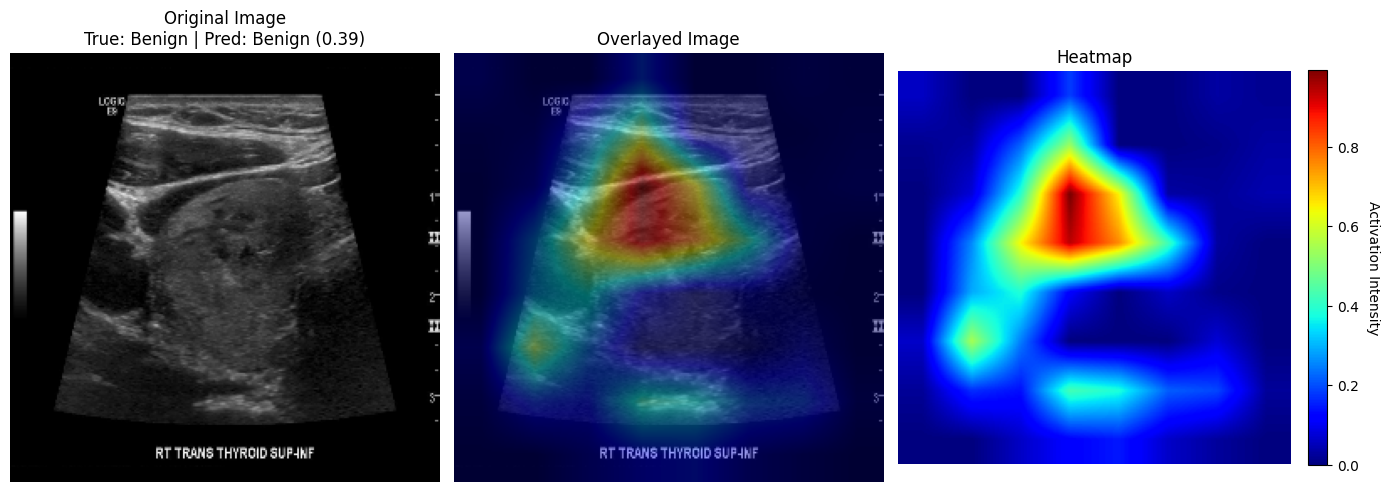

In [43]:
# model = models.load_model("Thyroid_PatientSplit_Best.keras")

try:
    random_row = test_df.sample(1).iloc[0]
    img_path = random_row['path']
    true_label = random_row['label']

    print(f"Image Loading: {img_path}")

    original_img_bgr = cv2.imread(img_path)

    if original_img_bgr is None:
        raise FileNotFoundError(f"Error: Could not load image from {img_path}")

    original_img_rgb = cv2.cvtColor(original_img_bgr, cv2.COLOR_BGR2RGB)

    original_img_resized = cv2.resize(original_img_rgb, (256, 256))

    img_input = original_img_resized.copy().astype(np.float32)
    img_input = tf.keras.applications.efficientnet.preprocess_input(img_input)
    img_array = np.expand_dims(img_input, axis=0)

    last_conv_layer_name = 'top_activation'

    heatmap_model = tf.keras.models.Model(
        inputs=best_model.input,
        outputs=[best_model.get_layer(last_conv_layer_name).output, best_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = heatmap_model(img_array)

        pred_prob = predictions[0][0]
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    if pred_prob < 0.5:
        grads = -grads

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    heatmap = heatmap.numpy().astype(np.float32)

    heatmap_resized = cv2.resize(heatmap, (original_img_resized.shape[1], original_img_resized.shape[0]))

    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_colored_bgr = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored_rgb = cv2.cvtColor(heatmap_colored_bgr, cv2.COLOR_BGR2RGB)

    superimposed_img = cv2.addWeighted(original_img_resized, 0.6, heatmap_colored_rgb, 0.4, 0)

    plt.figure(figsize=(14, 5))

    pred_label_text = "Malignant" if pred_prob > 0.5 else "Benign"
    true_label_text = "Malignant" if true_label == 1 else "Benign"

    plt.subplot(1, 3, 1)
    plt.imshow(original_img_resized)
    plt.title(f"Original Image\nTrue: {true_label_text} | Pred: {pred_label_text} ({pred_prob:.2f})")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(superimposed_img)
    plt.title("Overlayed Image")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    heatmap_plot = plt.imshow(heatmap_resized, cmap='jet')
    plt.title("Heatmap")
    plt.axis("off")

    cbar = plt.colorbar(heatmap_plot, fraction=0.046, pad=0.04)
    cbar.set_label("Activation Intensity", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"\nCritical Error: {e}")